# Discovering Question Types: Bernoulli Mixtures from MLE to Variational EM

**AI Disclaimer: this notebook was almost entirely generated by Claude Opus 4.6. I have checked that it runs and produces reasonable outputs.**

**Estimated time: ~60 minutes**

When we evaluate LLMs on benchmarks like MMLU, we observe a binary matrix: each model either gets a question right or wrong. But not all questions are the same — some test math, some test reasoning, some test memorization. Can we discover these latent question types purely from the pattern of correct and incorrect answers?

In this notebook, we model this with a **Bernoulli mixture model** and build up three increasingly sophisticated estimation methods:

1. **MLE** — when question types are known (just counting)
2. **EM** — when question types are latent (the classic algorithm)
3. **Variational EM** — adding priors for regularization and uncertainty

The progression mirrors the lecture material: likelihoods and MLE (Bayesian Inference notes), EM (EM/GMM notes, §4), and variational methods (EM/GMM notes, §5). The key insight is that the *framework* is the same across different distributions — once you've seen it for Gaussians, Bernoullis work identically.

**Pedagogical note**: This model may not be the most appropriate for this kind of data, but it helps illustrate these concepts well. For more sophisticated models, see the related work at the bottom.

---

## Part 0: Setup and Data

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import digamma, gammaln

np.random.seed(42)

plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['font.size'] = 12

### The model

We observe a binary matrix $\mathbf{X}$ of shape (Q questions) $\times$ (M models). Entry $x_{qm} = 1$ if model $m$ answered question $q$ correctly.

We posit $K$ latent **question types** (say math, reasoning, coding, etc.). The generative story:
1. Draw mixing weights: each question's type $z_q \sim \text{Categorical}(\boldsymbol{\pi})$, where $\pi_k = P(\text{type}=k)$
2. Draw outcomes: $x_{qm} \sim \text{Bernoulli}(\theta_{km})$, where $\theta_{km}$ is the accuracy of model $m$ on questions of type $k$

The parameters are:
- $\boldsymbol{\pi} \in \Delta^{K-1}$: mixing weights (how common each question type is)
- $\boldsymbol{\theta} \in [0,1]^{K \times M}$: per-type, per-model accuracy

This is a **Bernoulli mixture model** — structurally identical to a Gaussian mixture, but with Bernoulli observations instead of Gaussian ones.

### Generating synthetic benchmark data

In [2]:
# Ground-truth model skills (you won't peek at these during estimation!)
model_names = [
    "GPT-4o", "Claude-3.5", "Gemini-Pro", "Llama-405B",
    "Mistral-L", "GPT-3.5", "Llama-70B", "Mixtral", "Phi-3", "Vicuna"
]
type_names = ["Math/Reasoning", "Knowledge/Recall", "Coding"]
M = len(model_names)
K_true = len(type_names)

# True per-type accuracies: theta[k, m] = P(correct | type k, model m)
# Each type has a clearly distinct pattern of model strengths
true_theta = np.array([
    # Math/Reasoning: frontier models excel, small models struggle badly
    [0.95, 0.93, 0.88, 0.80, 0.45, 0.20, 0.35, 0.25, 0.30, 0.10],
    # Knowledge/Recall: most models are decent, compressed range
    [0.90, 0.88, 0.87, 0.85, 0.82, 0.80, 0.78, 0.75, 0.65, 0.60],
    # Coding: surprising pattern — Claude, Mistral, Phi-3 shine
    [0.75, 0.98, 0.65, 0.72, 0.92, 0.25, 0.60, 0.50, 0.90, 0.08],
])

# True mixing weights
true_pi = np.array([0.30, 0.45, 0.25])

# Generate Q questions
Q = 800
true_z = np.random.choice(K_true, size=Q, p=true_pi)

X = np.zeros((Q, M), dtype=int)
for q in range(Q):
    k = true_z[q]
    X[q] = np.random.binomial(1, true_theta[k])

print(f"Data matrix X: {Q} questions x {M} models")
print(f"Type distribution: {np.bincount(true_z, minlength=K_true)}")
print(f"Overall accuracy per model:")
for m, name in enumerate(model_names):
    print(f"  {name:>12s}: {X[:, m].mean():.1%}")

Data matrix X: 800 questions x 10 models
Type distribution: [247 349 204]
Overall accuracy per model:
        GPT-4o: 89.0%
    Claude-3.5: 91.8%
    Gemini-Pro: 81.8%
    Llama-405B: 81.0%
     Mistral-L: 73.0%
       GPT-3.5: 48.1%
     Llama-70B: 61.5%
       Mixtral: 53.0%
         Phi-3: 59.4%
        Vicuna: 31.5%


### Exploring the data

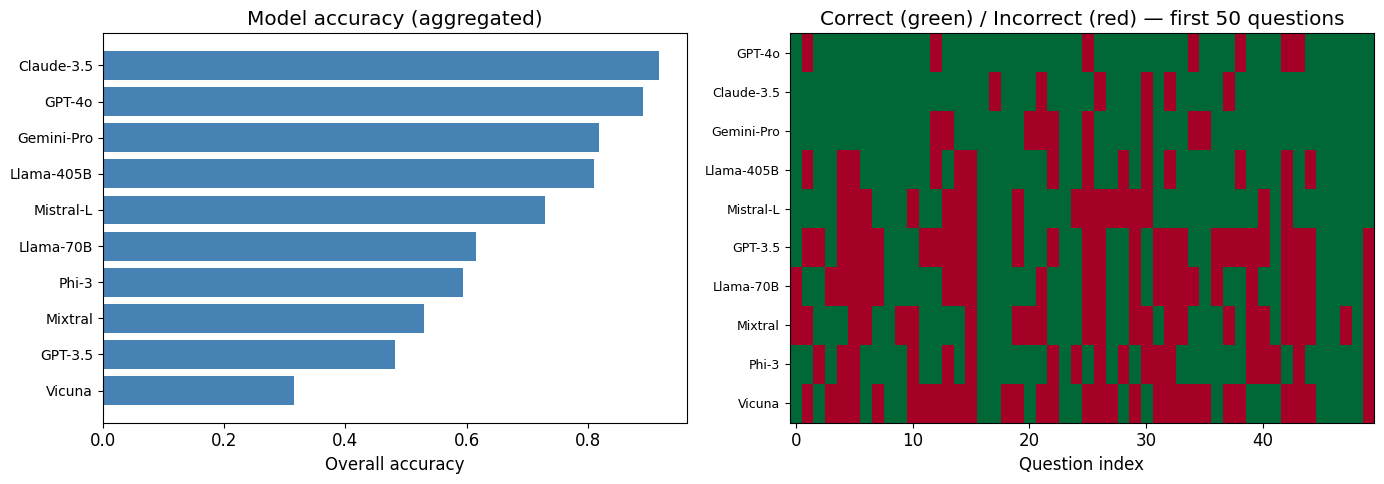

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: overall accuracy
ax = axes[0]
acc = X.mean(axis=0)
sort_idx = np.argsort(-acc)
ax.barh(range(M), acc[sort_idx], color='steelblue')
ax.set_yticks(range(M))
ax.set_yticklabels([model_names[i] for i in sort_idx], fontsize=10)
ax.set_xlabel("Overall accuracy")
ax.set_title("Model accuracy (aggregated)")
ax.invert_yaxis()

# Right: snippet of the binary matrix (first 50 questions)
ax = axes[1]
ax.imshow(X[:50].T, cmap='RdYlGn', aspect='auto', interpolation='nearest')
ax.set_xlabel("Question index")
ax.set_yticks(range(M))
ax.set_yticklabels(model_names, fontsize=9)
ax.set_title("Correct (green) / Incorrect (red) — first 50 questions")

plt.tight_layout()
plt.show()

The aggregate accuracy hides a lot of structure. Our goal is to discover the *types* of questions — clusters with distinct difficulty profiles — from the raw binary matrix alone.

---

## Part 1: Maximum Likelihood Estimation (types known)

If we magically knew each question's type $z_q$, estimation would be trivial.

### Exercise 1: MLE with known types

Given the true labels `true_z`, estimate $\hat{\theta}_{km}$ and $\hat{\pi}_k$ by counting.

Recall from the Bayesian inference lecture: the MLE for a Bernoulli parameter is just the empirical mean — number of successes over number of trials.

In [4]:
def mle_known_types(X, z, K):
    '''
    MLE when question types are known.

    Args:
        X: binary matrix (Q, M)
        z: type assignments, integer array of length Q
        K: number of types

    Returns:
        theta_hat: (K, M) estimated accuracies
        pi_hat: (K,) estimated mixing weights
    '''
    Q, M = X.shape
    theta_hat = np.zeros((K, M))
    pi_hat = np.zeros(K)

    for k in range(K):
        mask = (z == k)  # boolean array: which questions are type k
        # TODO: estimate pi_hat[k] and theta_hat[k, :] from the data
        # ---- YOUR CODE HERE ----
        pi_hat[k] = np.mean(mask)


        theta_hat[k, :] = X[mask, :].mean(axis=0)
        # ---- END YOUR CODE ----

    return theta_hat, pi_hat

theta_mle, pi_mle = mle_known_types(X, true_z, K_true)

print("True vs MLE mixing weights:")
for k in range(K_true):
    print(f"  {type_names[k]:>18s}: true={true_pi[k]:.2f}, MLE={pi_mle[k]:.2f}")

print("\nTrue vs MLE accuracies (first 4 models):")
for k in range(K_true):
    print(f"  {type_names[k]}:")
    for m in range(4):
        print(f"    {model_names[m]:>12s}: true={true_theta[k,m]:.2f}, MLE={theta_mle[k,m]:.2f}")

True vs MLE mixing weights:
      Math/Reasoning: true=0.30, MLE=0.31
    Knowledge/Recall: true=0.45, MLE=0.44
              Coding: true=0.25, MLE=0.26

True vs MLE accuracies (first 4 models):
  Math/Reasoning:
          GPT-4o: true=0.95, MLE=0.97
      Claude-3.5: true=0.93, MLE=0.91
      Gemini-Pro: true=0.88, MLE=0.88
      Llama-405B: true=0.80, MLE=0.79
  Knowledge/Recall:
          GPT-4o: true=0.90, MLE=0.92
      Claude-3.5: true=0.88, MLE=0.88
      Gemini-Pro: true=0.87, MLE=0.88
      Llama-405B: true=0.85, MLE=0.87
  Coding:
          GPT-4o: true=0.75, MLE=0.74
      Claude-3.5: true=0.98, MLE=0.98
      Gemini-Pro: true=0.65, MLE=0.63
      Llama-405B: true=0.72, MLE=0.73


### Why we need EM

In practice, we don't know $z_q$. We'd like to maximize the *marginal* log-likelihood:

$$\ell(\boldsymbol{\theta}, \boldsymbol{\pi}) = \sum_{q=1}^{Q} \log \underbrace{\sum_{k=1}^{K} \pi_k \prod_{m=1}^{M} \theta_{km}^{x_{qm}} (1-\theta_{km})^{1-x_{qm}}}_{\text{sum inside the log!}}$$

That sum inside the log blocks a clean closed-form solution — exactly the same issue as with GMMs (EM/GMM notes, eq. 1 and §4.1). The EM algorithm resolves this.

---

## Part 2: Expectation-Maximization

### The EM algorithm for Bernoulli mixtures

Just as in GMMs, EM alternates between two steps:

**E-step:** Compute *responsibilities* — the posterior probability that question $q$ belongs to type $k$:

$$r_{qk} = \frac{\pi_k \prod_{m=1}^{M} \theta_{km}^{x_{qm}}(1-\theta_{km})^{1-x_{qm}}}{\sum_{k'=1}^{K} \pi_{k'} \prod_{m=1}^{M} \theta_{k'm}^{x_{qm}}(1-\theta_{k'm})^{1-x_{qm}}}$$

Compare this to the GMM E-step: the structure is identical, but we've replaced the Gaussian density with the Bernoulli likelihood.

**M-step:** Update parameters using weighted counts (just like GMMs use weighted means):

$$\hat{\theta}_{km} = \frac{\sum_q r_{qk}\, x_{qm}}{\sum_q r_{qk}}, \qquad \hat{\pi}_k = \frac{1}{Q}\sum_q r_{qk}$$

Notice: $\hat{\theta}_{km}$ is a *weighted* empirical mean — the "soft" version of the counting we did in Part 1. When $r_{qk} \in \{0, 1\}$ (hard assignments), this reduces exactly to the MLE from Exercise 1.

### Exercise 2: Implement the E-step

In [5]:
def e_step(X, theta, pi):
    '''
    Compute responsibilities r[q, k] = P(z_q = k | x_q, theta, pi).

    Args:
        X: (Q, M) binary matrix
        theta: (K, M) per-type accuracies
        pi: (K,) mixing weights

    Returns:
        r: (Q, K) responsibilities
    '''
    Q, M = X.shape
    K = len(pi)
    log_r = np.zeros((Q, K))

    for k in range(K):
        # TODO: compute the (unnormalized) log-responsibility for type k.
        # Use np.clip(theta[k], 1e-10, 1-1e-10) to avoid log(0).
        # You can vectorize this code, but it is also ok to loop
        # ---- YOUR CODE HERE ----
        th = np.clip(theta[k], 1e-10, 1 - 1e-10)
        log_likelihood = X * np.log(th) + (1 - X) * np.log(1 - th)
        log_r[:, k] = np.log(pi[k]) + log_likelihood.sum(axis=1)
        # ---- END YOUR CODE ----

    # Normalize: convert log-responsibilities to responsibilities using log-sum-exp
    log_r_max = log_r.max(axis=1, keepdims=True)
    log_r = log_r - log_r_max  # for numerical stability
    r = np.exp(log_r)
    r = r / r.sum(axis=1, keepdims=True)

    return r

# Quick test: with true parameters, responsibilities should be close to true assignments
r_test = e_step(X, true_theta, true_pi)
pred_z = r_test.argmax(axis=1)
accuracy = (pred_z == true_z).mean()
print(f"With true parameters, assignment accuracy: {accuracy:.1%}")

With true parameters, assignment accuracy: 82.2%


<details>
<summary><b>Click for hint</b></summary>

This is: `log(pi_k) + sum_m [x_qm * log(theta_km) + (1-x_qm) * log(1-theta_km)]`
        
`X` is `(Q, M)` and `theta[k]` is `(M,)`. Vectorize over q!
</details>

### Exercise 3: Implement the M-step

In [6]:
def m_step(X, r):
    '''
    Update parameters given responsibilities.

    Args:
        X: (Q, M) binary matrix
        r: (Q, K) responsibilities

    Returns:
        theta_new: (K, M) updated accuracies
        pi_new: (K,) updated mixing weights
    '''
    Q, M = X.shape
    K = r.shape[1]
    theta_new = np.zeros((K, M))
    pi_new = np.zeros(K)

    for k in range(K):
        N_k = r[:, k].sum()  # effective number of questions in type k
        # TODO: compute theta_new[k] and pi_new[k]
        # ---- YOUR CODE HERE ----
        pi_new[k] = N_k / Q

        theta_new[k, :] = (X * r[:, k:k+1]).sum(axis=0) / N_k
        # ---- END YOUR CODE ----

    return theta_new, pi_new

# Quick test
r_test = e_step(X, true_theta, true_pi)
theta_test, pi_test = m_step(X, r_test)
print("M-step mixing weights:", np.round(pi_test, 3))
print("True mixing weights:  ", np.round(true_pi, 3))

M-step mixing weights: [0.313 0.439 0.248]
True mixing weights:   [0.3  0.45 0.25]


<details>
<summary><b>Click for hint</b></summary>

```
theta_new[k, m] = (weighted sum of x_qm) / N_k
pi_new[k] = N_k / Q
```
</details>

### Exercise 4: Put it together — the full EM loop

In [8]:
def compute_log_likelihood(X, theta, pi):
    '''Compute the marginal log-likelihood.'''
    Q, M = X.shape
    K = len(pi)
    ll = 0.0
    for q in range(Q):
        p_q = 0.0
        for k in range(K):
            th = np.clip(theta[k], 1e-10, 1 - 1e-10)
            log_p = np.log(pi[k]) + np.sum(X[q] * np.log(th) + (1 - X[q]) * np.log(1 - th))
            p_q += np.exp(log_p)
        ll += np.log(p_q + 1e-300)
    return ll


def run_em(X, K, n_iter=50, seed=1):
    '''
    Run EM for a Bernoulli mixture model.

    Args:
        X: (Q, M) binary data
        K: number of types
        n_iter: number of iterations
        seed: random seed for initialization

    Returns:
        theta, pi, responsibilities, log-likelihood history
    '''
    np.random.seed(seed)
    Q, M = X.shape

    # Random initialization
    theta = np.random.beta(2, 2, size=(K, M))  # random accuracies near 0.5
    pi = np.ones(K) / K                         # uniform mixing weights

    ll_history = []

    for it in range(n_iter):
        # TODO: call e_step and m_step
        # ---- YOUR CODE HERE ----
        r = e_step(X, theta, pi)
        theta, pi = m_step(X, r)
        # ---- END YOUR CODE ----

        ll = compute_log_likelihood(X, theta, pi)
        ll_history.append(ll)

        if it < 3 or (it + 1) % 10 == 0:
            print(f"  Iter {it+1:3d}: log-likelihood = {ll:.1f}")

    return theta, pi, r, ll_history

print("Running EM with K=3...")
theta_em, pi_em, r_em, ll_hist = run_em(X, K=3, n_iter=40)

Running EM with K=3...
  Iter   1: log-likelihood = -4366.8
  Iter   2: log-likelihood = -4317.5
  Iter   3: log-likelihood = -4296.8
  Iter  10: log-likelihood = -4280.5
  Iter  20: log-likelihood = -4235.0
  Iter  30: log-likelihood = -4215.9
  Iter  40: log-likelihood = -4212.2


### EM convergence

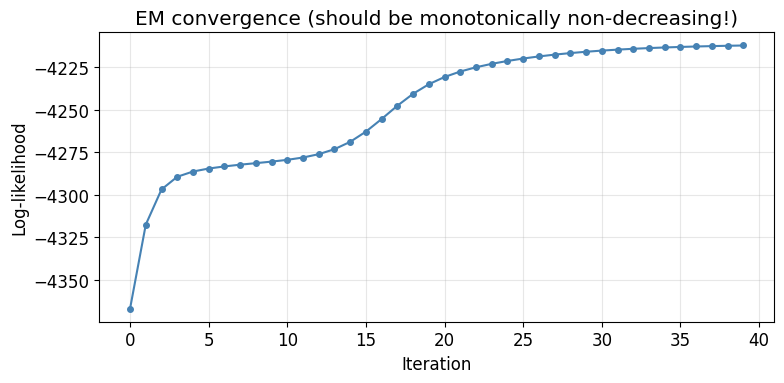

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ll_hist, 'o-', color='steelblue', markersize=4)
ax.set_xlabel("Iteration")
ax.set_ylabel("Log-likelihood")
ax.set_title("EM convergence (should be monotonically non-decreasing!)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Interpreting the discovered types

EM discovers the types purely from the pattern of correct/incorrect answers. Let's see if the discovered types match the true ones.

*Note:* The type labels (0, 1, 2) may be permuted relative to the true labels — EM doesn't know which cluster is "Math" vs "Knowledge". We'll match them by finding the best alignment.

Best cluster alignment accuracy: 79.5%
Permutation: EM cluster [0, 1, 2] -> true type [2, 1, 0]


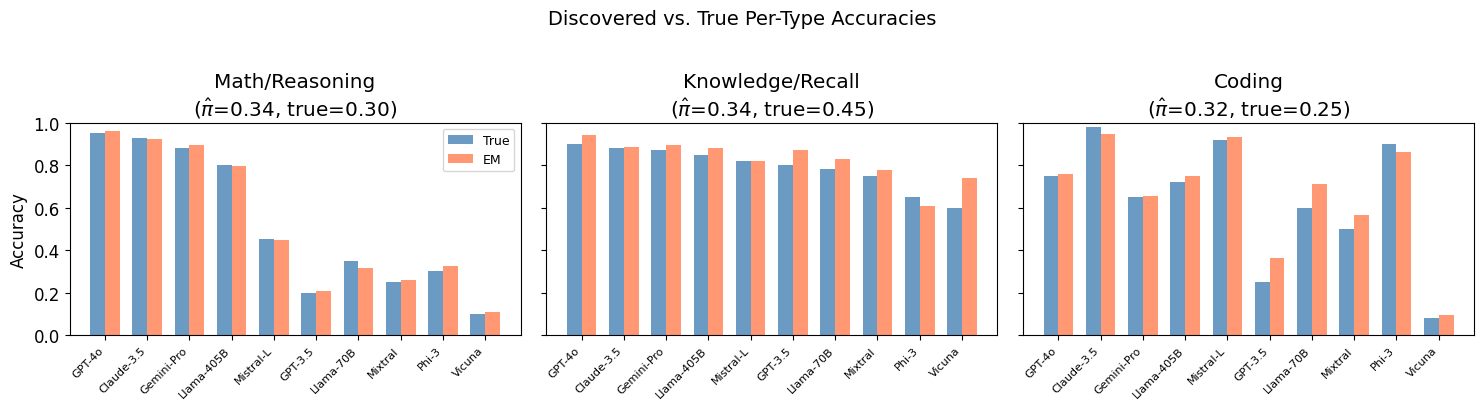

In [10]:
from itertools import permutations

def match_clusters(true_z, pred_z, K):
    '''Find the permutation of predicted labels that best matches true labels.'''
    best_acc = 0
    best_perm = None
    for perm in permutations(range(K)):
        remapped = np.array([perm[p] for p in pred_z])
        acc = (remapped == true_z).mean()
        if acc > best_acc:
            best_acc = acc
            best_perm = perm
    return best_perm, best_acc

pred_z = r_em.argmax(axis=1)
best_perm, match_acc = match_clusters(true_z, pred_z, K_true)
print(f"Best cluster alignment accuracy: {match_acc:.1%}")
print(f"Permutation: EM cluster {list(range(K_true))} -> true type {list(best_perm)}")

# Reorder EM results to match true labels
perm_idx = list(best_perm)
theta_em_aligned = theta_em[perm_idx]
pi_em_aligned = pi_em[perm_idx]

# Visualize: true vs estimated accuracies
fig, axes = plt.subplots(1, K_true, figsize=(15, 4), sharey=True)
x_pos = np.arange(M)
width = 0.35

for k in range(K_true):
    ax = axes[k]
    ax.bar(x_pos - width/2, true_theta[k], width, label='True', color='steelblue', alpha=0.8)
    ax.bar(x_pos + width/2, theta_em_aligned[k], width, label='EM', color='coral', alpha=0.8)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(model_names, rotation=45, ha='right', fontsize=8)
    ax.set_title(f"{type_names[k]}\n($\\hat\\pi$={pi_em_aligned[k]:.2f}, true={true_pi[k]:.2f})")
    ax.set_ylim(0, 1)
    if k == 0:
        ax.set_ylabel("Accuracy")
        ax.legend(fontsize=9)

plt.suptitle("Discovered vs. True Per-Type Accuracies", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Discussion:** EM recovers the question types and per-type accuracies purely from the binary response pattern — no labels needed! Each "type" has a distinct *profile* of which models are strong and which are weak.

---

## Part 3: Variational EM — Adding Priors

### Why priors?

What if some question type has very few examples? The MLE estimate $\hat{\theta}_{km}$ could be 0 or 1, which is overconfident. And with many types or few questions, EM can overfit.

The fix: place **priors** on the parameters and do **Bayesian** estimation. We use conjugate priors so everything stays in closed form — no gradient descent needed!

**Prior on accuracies:** $\theta_{km} \sim \text{Beta}(\alpha, \beta)$

This connects directly to the Beta-Binomial conjugacy from the Bayesian Inference lecture. With $\alpha = \beta = 2$, the prior gently favors accuracies near 0.5.

**Prior on mixing weights:** $\boldsymbol{\pi} \sim \text{Dirichlet}(\gamma_1, \ldots, \gamma_K)$

This is the multinomial analog — same idea as the Dirichlet prior in the Gibbs sampling reading (§2.2).

### The variational updates

In variational EM, the E-step stays essentially the same, but the M-step is replaced by computing expectations under the variational posterior. The key change: instead of point estimates, we maintain *posterior parameters* that incorporate pseudo-counts from the prior.

**Variational M-step for $\theta_{km}$:**

$$\tilde{\alpha}_{km} = \alpha + \sum_q r_{qk}\, x_{qm}, \qquad \tilde{\beta}_{km} = \beta + \sum_q r_{qk}\,(1 - x_{qm})$$

The expected accuracy under this posterior is $\mathbb{E}[\theta_{km}] = \frac{\tilde{\alpha}_{km}}{\tilde{\alpha}_{km} + \tilde{\beta}_{km}}$

Compare this to the MLE: $\hat{\theta}_{km} = \frac{\sum_q r_{qk} x_{qm}}{\sum_q r_{qk}}$. The prior adds $\alpha - 1$ "pseudo-successes" and $\beta - 1$ "pseudo-failures" — exactly the pseudocount interpretation from the lecture!

**Variational E-step** (the only change from standard EM):

Use $\mathbb{E}[\log \theta_{km}] = \psi(\tilde{\alpha}_{km}) - \psi(\tilde{\alpha}_{km} + \tilde{\beta}_{km})$ instead of $\log \theta_{km}$, where $\psi$ is the digamma function. Similarly for $\log(1-\theta_{km})$ and $\log \pi_k$.

### Exercise 5: Implement Variational EM

In [ ]:
def variational_e_step(X, alpha_post, beta_post, gamma_post):
    '''
    Variational E-step: use expected log-parameters instead of point estimates.

    Args:
        X: (Q, M) data
        alpha_post: (K, M) posterior alpha for Beta
        beta_post: (K, M) posterior beta for Beta
        gamma_post: (K,) posterior parameters for Dirichlet

    Returns:
        r: (Q, K) responsibilities
    '''
    Q, M = X.shape
    K = len(gamma_post)
    log_r = np.zeros((Q, K))

    for k in range(K):
        # Expected log-parameters under the variational posterior
        E_log_theta = digamma(alpha_post[k]) - digamma(alpha_post[k] + beta_post[k])
        E_log_1mtheta = digamma(beta_post[k]) - digamma(alpha_post[k] + beta_post[k])
        E_log_pi_k = digamma(gamma_post[k]) - digamma(gamma_post.sum())

        # TODO: compute log_r[:, k] using the expected log-parameters
        # Same structure as the standard E-step, but replace log(theta) with E[log(theta)], etc.
        # ---- YOUR CODE HERE ----

        # ---- END YOUR CODE ----

    # Normalize
    log_r -= log_r.max(axis=1, keepdims=True)
    r = np.exp(log_r)
    r /= r.sum(axis=1, keepdims=True)
    return r


def variational_m_step(X, r, alpha_prior, beta_prior, gamma_prior):
    '''
    Variational M-step: update posterior parameters by adding pseudo-counts.

    Args:
        X: (Q, M) data
        r: (Q, K) responsibilities
        alpha_prior, beta_prior: scalar priors for Beta
        gamma_prior: scalar prior for Dirichlet (same for all k)

    Returns:
        alpha_post: (K, M) posterior alpha
        beta_post: (K, M) posterior beta
        gamma_post: (K,) posterior gamma
    '''
    Q, M = X.shape
    K = r.shape[1]

    alpha_post = np.zeros((K, M))
    beta_post = np.zeros((K, M))
    gamma_post = np.zeros(K)

    for k in range(K):
        N_k = r[:, k].sum()
        weighted_sum = r[:, k] @ X  # shape (M,)

        # TODO: update the posterior parameters
        # ---- YOUR CODE HERE ----

        # ---- END YOUR CODE ----

    return alpha_post, beta_post, gamma_post

<details>
<summary><b>Click for hint</b></summary>

```
alpha_post[k] = alpha_prior + (weighted successes)
beta_post[k] = beta_prior + (weighted failures)
gamma_post[k] = gamma_prior + N_k
```
</details>

In [ ]:
def run_variational_em(X, K, alpha_prior=2.0, beta_prior=2.0, gamma_prior=1.0,
                       n_iter=40, seed=1):
    '''Run variational EM.'''
    np.random.seed(seed)
    Q, M = X.shape

    # Initialize posterior parameters randomly
    alpha_post = np.random.gamma(5, 1, size=(K, M))
    beta_post = np.random.gamma(5, 1, size=(K, M))
    gamma_post = np.ones(K) * gamma_prior

    for it in range(n_iter):
        r = variational_e_step(X, alpha_post, beta_post, gamma_post)
        alpha_post, beta_post, gamma_post = variational_m_step(
            X, r, alpha_prior, beta_prior, gamma_prior)

        if it < 3 or (it + 1) % 10 == 0:
            theta_mean = alpha_post / (alpha_post + beta_post)
            pi_mean = gamma_post / gamma_post.sum()
            ll = compute_log_likelihood(X, theta_mean, pi_mean)
            print(f"  Iter {it+1:3d}: approx log-likelihood = {ll:.1f}")

    theta_mean = alpha_post / (alpha_post + beta_post)
    pi_mean = gamma_post / gamma_post.sum()
    return theta_mean, pi_mean, alpha_post, beta_post, gamma_post, r

print("Running Variational EM with K=3, Beta(2,2) prior...")
(theta_vem, pi_vem, alpha_post, beta_post, gamma_post, r_vem
 ) = run_variational_em(X, K=3, alpha_prior=2.0, beta_prior=2.0)

### The payoff: posterior uncertainty on accuracies

In [ ]:
from scipy.stats import beta as beta_dist

# Match clusters
pred_z_vem = r_vem.argmax(axis=1)
perm_vem, acc_vem = match_clusters(true_z, pred_z_vem, K_true)
print(f"VEM cluster alignment accuracy: {acc_vem:.1%}")

# Reorder
perm = list(perm_vem)
alpha_aligned = alpha_post[perm]
beta_aligned = beta_post[perm]

# Plot posterior distributions for a few (type, model) pairs
fig, axes = plt.subplots(K_true, 3, figsize=(12, 8))

# Pick 3 representative models
show_models = [0, 5, 9]  # GPT-4o, GPT-3.5, Vicuna

for ki, k in enumerate(range(K_true)):
    for mi, m in enumerate(show_models):
        ax = axes[ki, mi]
        a, b = alpha_aligned[k, m], beta_aligned[k, m]
        x_grid = np.linspace(0, 1, 200)
        pdf = beta_dist.pdf(x_grid, a, b)
        ax.fill_between(x_grid, pdf, alpha=0.3, color='steelblue')
        ax.plot(x_grid, pdf, color='steelblue', linewidth=2)
        ax.axvline(true_theta[k, m], color='green', linestyle='--',
                   linewidth=2, label=f'true={true_theta[k,m]:.2f}')
        ax.set_title(f"{type_names[k]}\n{model_names[m]}", fontsize=10)
        ax.set_xlim(0, 1)
        if ki == K_true - 1:
            ax.set_xlabel(r"$\theta$")
        if mi == 0:
            ax.set_ylabel("Density")
        ax.legend(fontsize=8, loc='upper left')

plt.suptitle("Posterior Beta Distributions over Accuracies", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

The posterior distributions show our **uncertainty** about each accuracy parameter. Models with more questions assigned to a type have tighter posteriors (less uncertainty). The true values (dashed green) should fall within the posterior mass.

Compare this to plain EM, which gives only point estimates — no indication of how confident we should be!

### Comparing MLE, EM, and Variational EM

In [ ]:
# Scatter: EM vs VEM estimates (both aligned)
theta_em_al = theta_em[list(best_perm)]
theta_vem_al = theta_vem[list(perm_vem)]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.scatter(true_theta.ravel(), theta_em_al.ravel(), alpha=0.6, s=30, label='EM')
ax.scatter(true_theta.ravel(), theta_vem_al.ravel(), alpha=0.6, s=30, marker='^', label='VEM')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_xlabel("True accuracy")
ax.set_ylabel("Estimated accuracy")
ax.set_title("EM vs Variational EM Accuracy Estimates")
ax.legend()
ax.grid(alpha=0.3)

# Show the effect of the prior: VEM shrinks extreme estimates toward 0.5
ax = axes[1]
diff_em = theta_em_al.ravel() - true_theta.ravel()
diff_vem = theta_vem_al.ravel() - true_theta.ravel()
ax.hist(diff_em, bins=20, alpha=0.5, label='EM error', color='steelblue')
ax.hist(diff_vem, bins=20, alpha=0.5, label='VEM error', color='coral')
ax.axvline(0, color='k', linestyle='--')
ax.set_xlabel("Estimation error")
ax.set_ylabel("Count")
ax.set_title("Distribution of Estimation Errors")
ax.legend()

plt.tight_layout()
plt.show()

print(f"Mean absolute error — EM: {np.abs(diff_em).mean():.4f}, VEM: {np.abs(diff_vem).mean():.4f}")

### Exercise 6: Effect of the prior strength

Try re-running variational EM with different prior strengths. What happens with $\alpha = \beta = 1$ (uniform / no prior)? With $\alpha = \beta = 10$ (strong prior pulling toward 0.5)?

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))


for idx, (a_prior, title) in enumerate([
    (1.0, "Weak prior: Beta(1,1)"),
    (2.0, "Moderate prior: Beta(2,2)"),
    (10.0, "Strong prior: Beta(10,10)")
]):
    theta_v, pi_v, _, _, _, r_v = run_variational_em(
        X, K=3, alpha_prior=a_prior, beta_prior=a_prior, n_iter=40, seed=0)
    perm_v, _ = match_clusters(true_z, r_v.argmax(axis=1), K_true)
    theta_v_al = theta_v[list(perm_v)]

    ax = axes[idx]
    ax.scatter(true_theta.ravel(), theta_v_al.ravel(), alpha=0.6, s=30, color='steelblue')
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
    ax.set_xlabel("True accuracy")
    ax.set_ylabel("VEM estimate")
    ax.set_title(title)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)
    mae = np.abs(theta_v_al - true_theta).mean()
    ax.annotate(f"MAE={mae:.3f}", xy=(0.05, 0.92), fontsize=10,
                xycoords='axes fraction')

plt.suptitle("Effect of Prior Strength on Accuracy Estimates", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## Bonus: Applying to Real MMLU-Pro Data

Let's try our model on real per-question evaluation data from [MMLU-Pro](https://huggingface.co/datasets/TIGER-Lab/MMLU-Pro), a challenging multi-task benchmark with 12K questions across 14 subjects. The data includes per-question correct/incorrect labels for 9 models ranging from Llama-2-7B to Claude 3.5 Sonnet.

*Data source: [ahoho/mmlu-pro-cleaned](https://github.com/ahoho/mmlu-pro-cleaned)*

In [ ]:
# Download the real data
import urllib.request, os
import json


data_url = "https://raw.githubusercontent.com/ahoho/mmlu-pro-cleaned/main/mmlu_pro_irt.jsonl"
data_path = "mmlu_pro_irt.jsonl"

if not os.path.exists(data_path):
    print("Downloading MMLU-Pro data...")
    urllib.request.urlretrieve(data_url, data_path)
    print("Done!")

# Load and pivot into binary matrix
records = []
with open(data_path) as f:
    for line in f:
        records.append(json.loads(line))

real_models = sorted(set(r['model'] for r in records))
real_questions = sorted(set(r['question_id'] for r in records))
q_to_idx = {q: i for i, q in enumerate(real_questions)}
m_to_idx = {m: i for i, m in enumerate(real_models)}

Q_real = len(real_questions)
M_real = len(real_models)
X_real = np.zeros((Q_real, M_real), dtype=int)
q_categories = [''] * Q_real

for r in records:
    X_real[q_to_idx[r['question_id']], m_to_idx[r['model']]] = r['correct_label']
    q_categories[q_to_idx[r['question_id']]] = r['category']

q_categories = np.array(q_categories)

# Use shorter display names
short_names = [m.split('/')[-1].split('-Instruct')[0].split('-2024')[0][:18]
               for m in real_models]

print(f"Data: {Q_real} questions x {M_real} models")
print(f"Models and accuracies:")
for m, name in enumerate(short_names):
    print(f"  {name:>18s}: {X_real[:, m].mean():.1%}")
print(f"\nCategories: {len(set(q_categories))}")

Data: 12032 questions x 9 models
Models and accuracies:
      Llama-2-70b-hf: 36.3%
       Llama-2-7b-hf: 18.3%
  Meta-Llama-3_1-70B: 62.8%
   Meta-Llama-3_1-8B: 44.2%
        Mixtral-8x7B: 41.9%
   claude-3-5-sonnet: 77.6%
            gemma-7b: 32.4%
              gpt-4o: 74.7%
         gpt-4o-mini: 63.1%

Categories: 14


### Running EM on real benchmark data

We'll subsample 3000 questions for speed, then run EM with K=4 clusters. The question is: what structure does EM find? Does it discover the 14 MMLU subjects, or something else?

In [ ]:
# Subsample for speed
np.random.seed(42)
sub_idx = np.random.choice(Q_real, size=3000, replace=False)
X_sub = X_real[sub_idx]
cats_sub = q_categories[sub_idx]

# Run EM
K_real = 4
theta_real, pi_real, r_real, ll_real = run_em(X_sub, K=K_real, n_iter=50, seed=1)

# Also run VEM for comparison
theta_vreal, pi_vreal, a_real, b_real, g_real, r_vreal = run_variational_em(
    X_sub, K=K_real, alpha_prior=2.0, beta_prior=2.0, n_iter=50, seed=1)

In [ ]:
# What did EM discover?
pred_real = r_real.argmax(axis=1)
sort_order = np.argsort(-pi_real)  # show largest cluster first

fig, axes = plt.subplots(1, K_real, figsize=(16, 4), sharey=True)

for plot_idx, k in enumerate(sort_order):
    mask = pred_real == k
    ax = axes[plot_idx]

    # Bar chart of per-model accuracy for this cluster
    accs = theta_real[k]
    model_order = np.argsort(-accs)
    ax.barh(range(M_real), accs[model_order], color='steelblue', alpha=0.8)
    ax.set_yticks(range(M_real))
    ax.set_yticklabels([short_names[i] for i in model_order], fontsize=8)
    ax.set_xlim(0, 1)
    ax.set_xlabel("Accuracy")
    ax.invert_yaxis()

    # Top categories in this cluster
    cat_counts = {}
    for c in cats_sub[mask]:
        cat_counts[c] = cat_counts.get(c, 0) + 1
    top_cats = sorted(cat_counts.items(), key=lambda x: -x[1])[:3]
    cat_str = ", ".join(f"{c}" for c, n in top_cats)
    ax.set_title(f"Cluster {plot_idx+1} ({mask.sum()} Qs, $\\pi$={pi_real[k]:.2f})\n{cat_str}",
                 fontsize=9)

plt.suptitle("Discovered Question Types in MMLU-Pro", fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

### What did we find?

EM doesn't recover the 14 MMLU subjects. Instead, it discovers **difficulty levels**: clusters where all models are accurate (easy questions), clusters where only frontier models succeed (medium), and clusters where even the best models struggle (hard). The categories within each cluster are mixed.

This makes sense! With only 9 models, the signal that distinguishes "math" from "physics" is weak — the models have similar *relative* strengths across STEM subjects. What varies most across questions is **overall difficulty**, which EM picks up on.

This is itself a useful insight: the main axis of variation in benchmark data is difficulty, not topic. To discover finer-grained topic structure, you'd need more models with diverse specializations (e.g., a code-specialized model, a medical model, etc.).

For a more sophisticated version of this analysis using Item Response Theory, see [Rodriguez et al. (ACL 2021)](https://aclanthology.org/2021.acl-long.346/).

In [ ]:
# Bonus visualization: category composition of each cluster
fig, axes = plt.subplots(1, K_real, figsize=(16, 5), sharey=True)

all_cats = sorted(set(q_categories))
colors = plt.cm.tab20(np.linspace(0, 1, len(all_cats)))
cat_to_color = dict(zip(all_cats, colors))

for plot_idx, k in enumerate(sort_order):
    mask = pred_real == k
    ax = axes[plot_idx]
    cat_counts = {c: 0 for c in all_cats}
    for c in cats_sub[mask]:
        cat_counts[c] += 1

    counts = [cat_counts[c] for c in all_cats]
    bars = ax.barh(range(len(all_cats)), counts,
                   color=[cat_to_color[c] for c in all_cats])
    ax.set_yticks(range(len(all_cats)))
    if plot_idx == 0:
        ax.set_yticklabels(all_cats, fontsize=8)
    else:
        ax.set_yticklabels([])
    ax.set_xlabel("# Questions")
    ax.set_title(f"Cluster {plot_idx+1}", fontsize=10)
    ax.invert_yaxis()

plt.suptitle("Category Composition of Discovered Clusters", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Exercise 7 (discussion)

1. **MLE → EM → Variational EM** follows the same pattern as the lecture's progression from known-$z$ estimation to GMM-EM to Variational EM. In both cases, the E-step computes responsibilities and the M-step does weighted counting. What changes between the Gaussian and Bernoulli versions? What stays the same?

2. The **Beta prior** on accuracies plays exactly the same role as the **Gaussian prior** on GMM means (or the Beta prior on the coin parameter from the Bayesian inference lecture). How do the pseudocount parameters $\alpha, \beta$ relate to the "number of prior observations" interpretation?

3. In variational EM, we replaced $\log \theta$ with $\mathbb{E}[\log \theta] = \psi(\alpha) - \psi(\alpha + \beta)$ (the digamma function). Why can't we just use $\log \mathbb{E}[\theta]$ instead? *(Hint: Jensen's inequality.)*

4. Our model assumes questions within a type are **exchangeable** — their outcomes are independent given the type. When might this assumption break down for real LLM benchmarks?

---

## Summary

| Method | Types known? | Parameters are... | Prior? | Key computation |
|--------|-------------|-------------------|--------|----------------|
| **MLE** | Yes | Point estimates | No | Count and normalize |
| **EM** | No (latent) | Point estimates | No | E: responsibilities, M: weighted counting |
| **Variational EM** | No (latent) | Posterior distributions | Yes | E: expected log-params, M: pseudo-count updates |

All updates are **closed-form** — no gradient descent anywhere. This is the power of conjugate priors (Beta-Bernoulli, Dirichlet-Categorical).

### Further reading

- **EM algorithm**: Dempster, Laird & Rubin (1977), "Maximum Likelihood from Incomplete Data via the EM Algorithm"
- **Variational inference**: Blei, Kucukelbir & McAuliffe (2017), "Variational Inference: A Review for Statisticians"
- **IRT for NLP leaderboards**: Rodriguez et al. (ACL 2021), [Evaluation Examples Are Not Equally Informative](https://aclanthology.org/2021.acl-long.346/) — applies a closely related Bayesian model to benchmark evaluation
- **MMLU-Pro benchmark**: Wang et al. (NeurIPS 2024), [MMLU-Pro dataset](https://huggingface.co/datasets/TIGER-Lab/MMLU-Pro)
